In [80]:
import pandas as pd
import numpy as np

In [81]:
df_pass = pd.read_csv('/Users/xaral/dev/xPass-Project/Week1_PandasBasics/data/week1_cleaned_passes.csv')
df_pass.head()

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,outcome,target,pass_receiver,end_location,start_x,start_y,end_x,end_y,player_name,body_part
0,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,Kick Off,2,"{'id': 28, 'name': 'AFC Bournemouth'}",From Kick Off,...,Complete,1,Joshua King,"[60.4, 43.6]",61.0,40.1,60.4,43.6,Dan Gosling,Right Foot
1,0fee7719-7e69-49c5-be81-3f2b77da604e,8,1,00:00:02.077,0,2,NaN,2,"{'id': 28, 'name': 'AFC Bournemouth'}",From Kick Off,...,Complete,1,Andrew Surman,"[48.0, 41.7]",60.4,43.6,48.0,41.7,Joshua King,Right Foot
2,6362aa69-892f-4d11-8644-21a680ea7c66,10,1,00:00:03.010,0,3,NaN,2,"{'id': 28, 'name': 'AFC Bournemouth'}",From Kick Off,...,Complete,1,Adam Smith,"[37.5, 76.1]",48.0,41.7,37.5,76.1,Andrew Surman,Left Foot
3,56da36e4-8b0d-4596-ba46-1d944c3d3f04,13,1,00:00:06.145,0,6,NaN,2,"{'id': 28, 'name': 'AFC Bournemouth'}",From Kick Off,...,Complete,1,Simon Francis,"[27.4, 58.1]",37.5,74.6,27.4,58.1,Adam Smith,Right Foot
4,bcfea2e3-9736-4975-be28-ef2c9d693fa7,16,1,00:00:09.350,0,9,NaN,2,"{'id': 28, 'name': 'AFC Bournemouth'}",From Kick Off,...,Complete,1,Adam Smith,"[35.1, 77.8]",27.4,63.9,35.1,77.8,Simon Francis,Right Foot


In [82]:
df_pass['start_x'].head()

0    61.0
1    60.4
2    48.0
3    37.5
4    27.4
Name: start_x, dtype: float64

In [83]:
def Pythagorean(x1, y1, x2, y2):
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

In [84]:
df_pass['pass_length_calc'] = Pythagorean(df_pass['start_x'], df_pass['start_y'], df_pass['end_x'], df_pass['end_y'])

In [85]:
df_pass['pass_length_calc'].head()

0     3.551056
1    12.544720
2    35.966790
3    19.345801
4    15.890249
Name: pass_length_calc, dtype: float64

In [86]:
print(df_pass['pass_length_calc'] - df_pass['length'])

0       8.091294e-08
1       4.846658e-09
2       2.376623e-07
3       5.779032e-07
4       5.820707e-07
            ...     
997    -1.410686e-06
998     2.615093e-06
999     5.983125e-07
1000   -5.997685e-07
1001   -1.107195e-07
Length: 1002, dtype: float64


In [87]:
x_opponentgoal = 120
y_opponentgoal = 40

In [88]:
df_pass['dist_togoal'] = Pythagorean(x_opponentgoal, y_opponentgoal, df_pass['end_x'], df_pass['end_y'])

In [89]:
df_pass['dist_togoal'].head()

0    59.708626
1    72.020067
2    90.052540
3    94.352371
4    92.934654
Name: dist_togoal, dtype: float64

In [90]:
def two_point_angle(x1, y1, x2, y2):
    return np.arctan2(y2-y1, x2-x1)

In [91]:
df_pass['pass_angle_calc'] = two_point_angle(df_pass['start_x'], df_pass['start_y'], df_pass['end_x'], df_pass['end_y'])

In [92]:
df_pass['pass_angle_calc'].head()

0    1.740575
1   -2.989549
2    1.867047
3   -2.120081
4    1.064920
Name: pass_angle_calc, dtype: float64

In [93]:
print(df_pass['angle'] - df_pass['pass_angle_calc'])

0      -7.632355e-10
1      -1.427362e-08
2       6.921696e-09
3      -1.569443e-07
4      -1.568109e-08
            ...     
997     2.474894e-08
998     2.110480e-09
999    -4.862032e-08
1000    4.409394e-08
1001   -9.948887e-10
Length: 1002, dtype: float64


In [94]:
%pip install mplsoccer matplotlib

Note: you may need to restart the kernel to use updated packages.


In [95]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

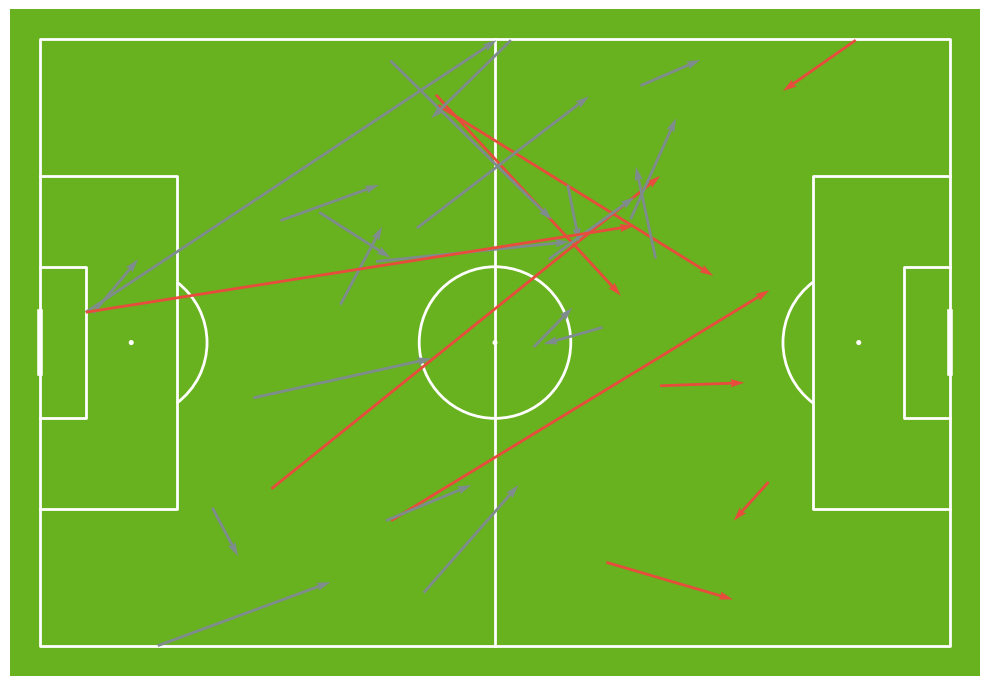

In [96]:
pitch = Pitch(pitch_type='statsbomb', pitch_color="#68b11f", line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

df_sample = df_pass.sample(n=30, random_state=42)

arrow_colors = np.where(df_sample['dist_togoal'] < 45, '#e74c3c', '#7f8c8d')
# Draw the passes, but color-code them by distance to the goal
pitch.arrows(
    df_sample['start_x'], 
    df_sample['start_y'],
    df_sample['end_x'], 
    df_sample['end_y'],
    width=2, 
    headwidth=3, 
    color=arrow_colors,  # 'c' stands for color data
    ax=ax
)
plt.show()

C:\Users\xaral\AppData\Local\Temp\ipykernel_22880\441197896.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')  # Try 'plasma' or 'viridis_r'—both look great on dark mode!


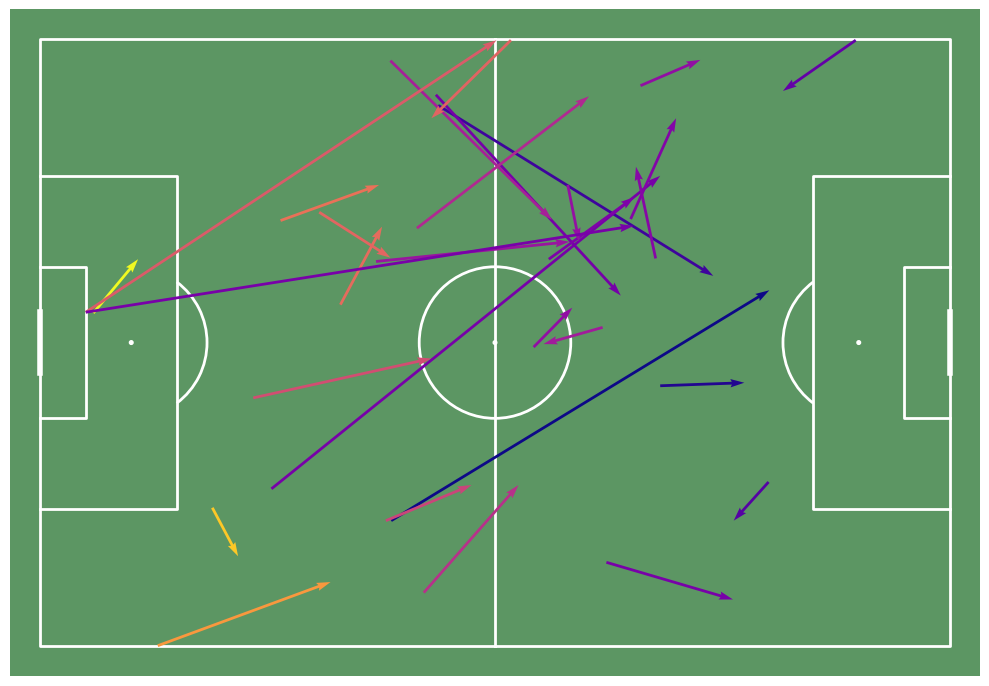

In [97]:
# --- RUN EVERYTHING IN ONE CELL ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mplsoccer import Pitch

# 1. Setup the field canvas
pitch = Pitch(pitch_type='statsbomb', pitch_color="#5c9663", line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# 2. Extract our reproducible random slice of data
df_sample = df_pass.sample(n=30, random_state=42)

# 3. Convert the distance column into an explicit array of RGBA color vectors
norm = mcolors.Normalize(vmin=df_sample['dist_togoal'].min(), vmax=df_sample['dist_togoal'].max())
cmap = cm.get_cmap('plasma')  # Try 'plasma' or 'viridis_r'—both look great on dark mode!
arrow_colors = cmap(norm(df_sample['dist_togoal']))

# 4. Paint the data vectors onto that specific canvas
pitch.arrows(
    df_sample['start_x'], 
    df_sample['start_y'],
    df_sample['end_x'], 
    df_sample['end_y'],
    width=2, 
    headwidth=3, 
    color=arrow_colors,  # Pass our clean array of mapped color vectors
    ax=ax
)

plt.show()

In [98]:
df_pass['player'].value_counts().head(10)

player
{'id': 3662, 'name': 'Danny Drinkwater'}    91
{'id': 3812, 'name': 'Christian Fuchs'}     82
{'id': 3961, 'name': "N''Golo Kanté"}       64
{'id': 3341, 'name': 'Steve Cook'}          58
{'id': 3345, 'name': 'Charlie Daniels'}     56
{'id': 3814, 'name': 'Riyad Mahrez'}        50
{'id': 3344, 'name': 'Andrew Surman'}       49
{'id': 20074, 'name': 'Artur Boruc'}        49
{'id': 6409, 'name': 'Adam Smith'}          46
{'id': 3270, 'name': 'Danny Simpson'}       46
Name: count, dtype: int64

In [99]:
df_mahrez = df_pass[df_pass['player_name'] == 'Riyad Mahrez']
df_mahrez

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,end_location,start_x,start_y,end_x,end_y,player_name,body_part,pass_length_calc,dist_togoal,pass_angle_calc
139,15366552-da47-405a-b547-bc89d113c93d,487,1,00:11:00.161,11,0,NaN,18,"{'id': 22, 'name': 'Leicester City'}",From Throw In,...,"[82.4, 55.5]",79.2,67.1,82.4,55.5,Riyad Mahrez,NaN,12.033287,40.669522,-1.301629
177,dfa7449b-d5b1-4b42-89ce-977c82fa8904,614,1,00:14:26.066,14,26,NaN,22,"{'id': 22, 'name': 'Leicester City'}",From Throw In,...,"[80.1, 64.5]",65.5,70.1,80.1,64.5,Riyad Mahrez,Left Foot,15.637135,46.821576,-0.366256
186,09cfc521-9ae6-4764-ab40-96fe6908bfb2,650,1,00:14:45.288,14,45,NaN,24,"{'id': 22, 'name': 'Leicester City'}",Regular Play,...,"[93.3, 0.8]",87.1,23.5,93.3,0.8,Riyad Mahrez,Left Foot,23.531468,47.429210,-1.304172
202,d0602ff7-b550-4689-b6a9-f8e76f663d0f,713,1,00:16:36.892,16,36,Recovery,29,"{'id': 28, 'name': 'AFC Bournemouth'}",Regular Play,...,"[56.7, 61.8]",52.7,66.9,56.7,61.8,Riyad Mahrez,Left Foot,6.481512,66.948712,-0.905694
204,ddf19774-40e8-4e01-952d-0ed8fc5dcfa2,723,1,00:16:41.933,16,41,NaN,29,"{'id': 28, 'name': 'AFC Bournemouth'}",Regular Play,...,"[43.1, 53.2]",51.6,59.8,43.1,53.2,Riyad Mahrez,Left Foot,10.761505,78.024676,-2.481364
209,143efb75-1894-463b-908d-68e2e85e1594,738,1,00:16:55.298,16,55,NaN,30,"{'id': 22, 'name': 'Leicester City'}",Regular Play,...,"[120.0, 54.9]",57.6,72.0,120.0,54.9,Riyad Mahrez,Left Foot,64.700618,14.900000,-0.267472
223,7effac67-5db0-4ad3-a687-ef71a6c3e6fe,780,1,00:17:57.651,17,57,NaN,32,"{'id': 22, 'name': 'Leicester City'}",Regular Play,...,"[110.6, 65.4]",88.4,50.6,110.6,65.4,Riyad Mahrez,Left Foot,26.681079,27.083574,0.588003
261,b2464f5c-dc7f-4ab2-b482-69bc3d54dc41,908,1,00:21:05.699,21,5,NaN,39,"{'id': 22, 'name': 'Leicester City'}",From Free Kick,...,"[55.9, 70.9]",72.8,67.1,55.9,70.9,Riyad Mahrez,Left Foot,17.321951,71.159117,2.920419
306,11679e4e-5c4e-4306-a957-8c1dc3a0b12d,1063,1,00:23:51.548,23,51,NaN,44,"{'id': 22, 'name': 'Leicester City'}",From Keeper,...,"[90.1, 52.6]",64.0,57.3,90.1,52.6,Riyad Mahrez,Left Foot,26.519804,32.446417,-0.178167
314,104e7b66-3595-46a1-863f-36a2430eb562,1090,1,00:24:13.922,24,13,NaN,44,"{'id': 22, 'name': 'Leicester City'}",From Keeper,...,"[52.7, 37.4]",79.0,51.7,52.7,37.4,Riyad Mahrez,Left Foot,29.936266,67.350204,-2.643579


In [100]:
df_pass.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'under_pressure', 'duel', 'ball_receipt', 'counterpress',
       'shot', 'goalkeeper', 'clearance', 'off_camera', 'out', 'dribble',
       'interception', 'foul_committed', 'foul_won', 'ball_recovery',
       'substitution', 'miscontrol', 'event_type', 'length', 'angle', 'height',
       'outcome', 'target', 'pass_receiver', 'end_location', 'start_x',
       'start_y', 'end_x', 'end_y', 'player_name', 'body_part',
       'pass_length_calc', 'dist_togoal', 'pass_angle_calc'],
      dtype='str')

In [101]:
df_mahrez['outcome']

139      Complete
177      Complete
186      Complete
202    Incomplete
204    Incomplete
209           Out
223      Complete
261      Complete
306      Complete
314      Complete
317      Complete
319      Complete
340      Complete
347      Complete
397      Complete
421      Complete
423      Complete
425      Complete
431      Complete
459      Complete
492      Complete
515    Incomplete
546      Complete
571      Complete
586    Incomplete
640      Complete
646      Complete
656    Incomplete
696    Incomplete
709      Complete
750      Complete
761      Complete
783      Complete
789    Incomplete
790      Complete
804      Complete
817      Complete
833      Complete
859      Complete
862      Complete
895      Complete
898    Incomplete
902    Incomplete
903      Complete
910      Complete
914      Complete
933    Incomplete
942      Complete
963      Complete
973      Complete
Name: outcome, dtype: str

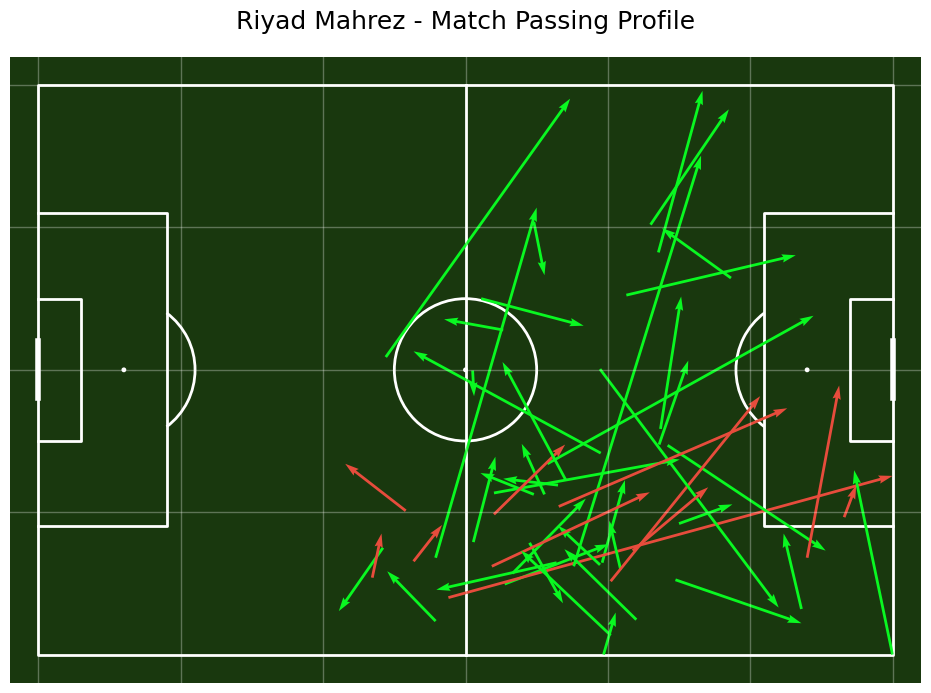

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch

pitch = Pitch(pitch_type='statsbomb', pitch_color="#19380e", line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

mahrez_colors = np.where(df_mahrez['outcome'] == 'Complete', "#09F821", '#e74c3c')

pitch.arrows(
    df_mahrez['start_x'], 
    df_mahrez['start_y'],
    df_mahrez['end_x'], 
    df_mahrez['end_y'],
    width=2, 
    headwidth=3, 
    color=mahrez_colors,  # 'c' stands for color data
    ax=ax
)

ax.set_title("Riyad Mahrez - Match Passing Profile", color='black', fontsize=18, pad=20)

for x in range(0, 121, 20):
    ax.axvline(x=x, color='white', alpha=0.3, lw=1)

for y in range(0, 61, 20):
    ax.axhline(y=y, color='white', alpha=0.3, lw=1)

plt.show()

In [103]:
df_pass['start_grid_x'] = df_pass['start_x'] //20
df_pass['start_grid_y'] = df_pass['start_y']//20
df_pass['end_grid_x'] = df_pass['end_x'] //20
df_pass['end_grid_y'] = df_pass['end_y']//20

In [104]:
df_pass['start_grid_x'] = df_pass['start_grid_x'].clip(lower=0, upper=5)
df_pass['start_grid_y'] = df_pass['start_grid_y'].clip(lower=0, upper=3)
df_pass['end_grid_x'] = df_pass['end_grid_x'].clip(lower=0, upper=5)
df_pass['end_grid_y'] = df_pass['end_grid_y'].clip(lower=0, upper=3)

In [105]:
df_pass[df_pass['start_grid_y'] >=4].count()

id                  0
index               0
period              0
timestamp           0
minute              0
second              0
type                0
possession          0
possession_team     0
play_pattern        0
team                0
duration            0
tactics             0
related_events      0
player              0
position            0
location            0
pass                0
carry               0
under_pressure      0
duel                0
ball_receipt        0
counterpress        0
shot                0
goalkeeper          0
clearance           0
off_camera          0
out                 0
dribble             0
interception        0
foul_committed      0
foul_won            0
ball_recovery       0
substitution        0
miscontrol          0
event_type          0
length              0
angle               0
height              0
outcome             0
target              0
pass_receiver       0
end_location        0
start_x             0
start_y             0
end_x     

In [106]:
passes_per_grid = np.zeros((4, 6), dtype=int)
for index, row in df_pass.iterrows():
    passes_per_grid[int(row['start_grid_y']), int(row['start_grid_x'])] +=1
print(passes_per_grid)

[[ 7 34 62 61 68 25]
 [39 56 62 43 36  6]
 [39 39 67 51 19  4]
 [15 52 91 75 31 20]]


In [107]:
destination_passes_per_grid = np.zeros((4,6), dtype=int)
for index, row in df_pass.iterrows():
    destination_passes_per_grid[int(row['end_grid_y']), int(row['end_grid_x'])] +=1
print(destination_passes_per_grid)

[[ 6 23 65 75 87 22]
 [16 37 50 53 34 38]
 [18 36 53 61 44 30]
 [ 8 35 81 69 43 18]]


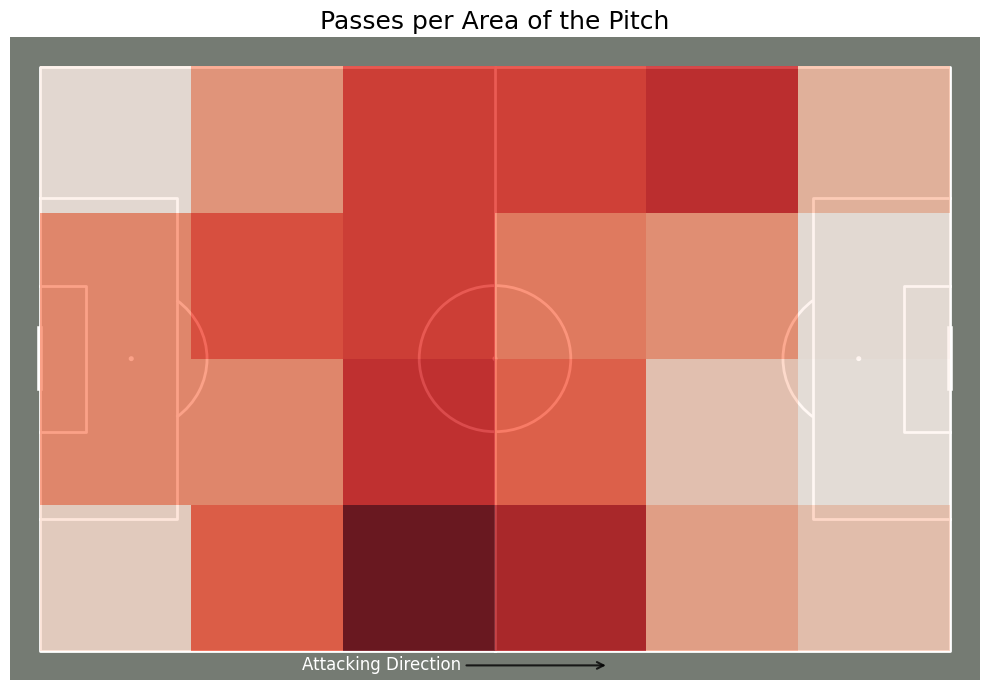

In [108]:
flipped_passes_per_grid = np.flipud(passes_per_grid)

pitch = Pitch(pitch_type='statsbomb', pitch_color="#757b73", line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))


ax.imshow(
    flipped_passes_per_grid,
    extent = [0,120,0,80],
    cmap='Reds',
    alpha=0.8,
    aspect='auto',
    zorder=1
)

arrow_design = dict(facecolor='white',arrowstyle= '->', lw=1.5, alpha=0.8)
ax.annotate(
    'Attacking Direction',
    xy=(75, 82),
    xytext=(45,82),
    arrowprops=arrow_design,
    ha='center',
    va='center',
    color='white',
    fontsize=12
)

plt.title("Passes per Area of the Pitch", fontsize=18, color='black')

plt.show()

In [109]:
success_per_grid = np.zeros((4,6), dtype=int)
for index, row in df_pass.iterrows():
    if(row['outcome'] == 'Complete'):
        success_per_grid[int(row['start_grid_y']), int(row['start_grid_x'])] +=1

success_rate_per_grid = np.divide(success_per_grid, passes_per_grid, out=np.zeros_like(success_per_grid, dtype=float), where=passes_per_grid!=0)

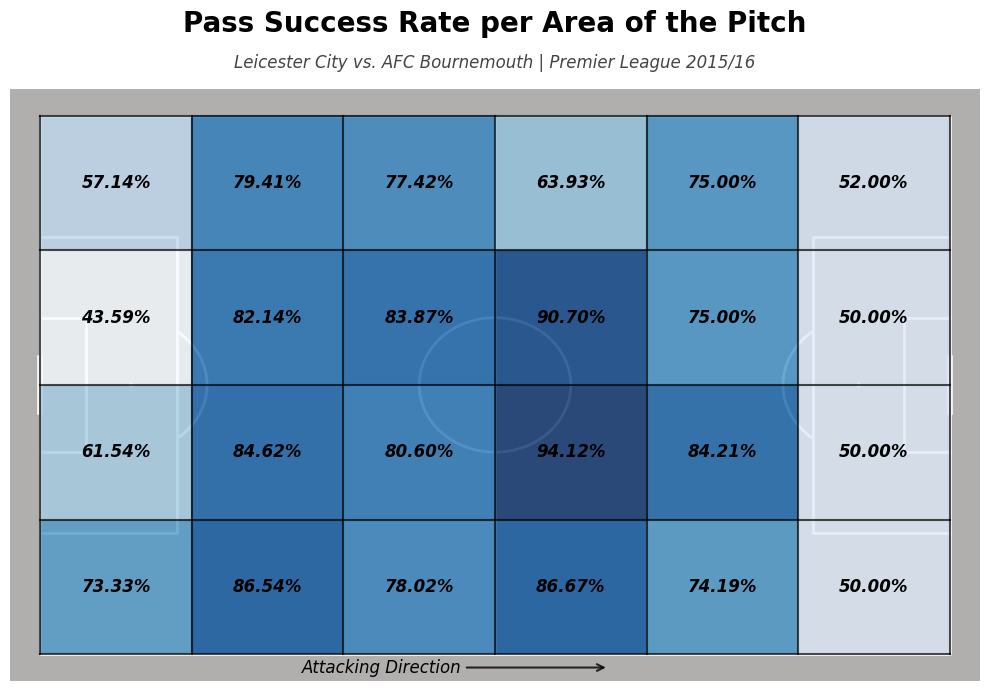

In [110]:
flipped_success_rate_per_grid = np.flipud(success_rate_per_grid)

pitch = Pitch(pitch_type='statsbomb', pitch_color="#b1aeaeff", line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

ax.imshow(
    flipped_success_rate_per_grid,
    extent = [0,120,0,80],
    cmap='Blues',
    alpha=0.8,
    aspect='auto',
    zorder=1
)

arrow_design = dict(facecolor='white',arrowstyle= '->', lw=1.5, alpha=0.8)
ax.annotate(
    'Attacking Direction',
    style='italic',
    fontname='DejaVu Sans',
    xy=(75, 82),
    xytext=(45,82),
    arrowprops=arrow_design,
    ha='center',
    va='center',
    color='black',
    fontsize=12
)

for x in range(0, 121, 20):
    ax.plot([x, x], [0, 80], color='black', alpha=0.7, lw=1.5, zorder=2)

for y in range(0, 81, 20):
    ax.plot([0,120], [y, y], color='black', alpha=0.7, lw=1.5, zorder=2)


for row_idx in range(4):
    for col_idx in range(6):
        success_rate = success_rate_per_grid[row_idx, col_idx]

        x_pos = col_idx *20 + 10
        y_pos = row_idx *20 + 10

        ax.text(
            x_pos,
            y_pos,
            f"{success_rate:.2%}",
            color='black',
            va='center', ha='center',
            fontsize=12, weight='bold',
            zorder=3,
            style='italic'
        )


# 1. Main Title (Sits at the very top of the figure canvas)
plt.suptitle(
    "Pass Success Rate per Area of the Pitch", 
    fontsize=20, 
    color='black', 
    weight='bold', 
    fontname='DejaVu Sans',
    y=0.98  # Anchors it cleanly at the top edge
)

# 2. Subtitle (Sits neatly directly beneath the main title and right above the pitch)
ax.set_title(
    "Leicester City vs. AFC Bournemouth | Premier League 2015/16", 
    fontsize=12, 
    color='#444444',       # Dark gray gives a high-end editorial feel
    style='italic',        # Italicized as requested earlier
    fontname='DejaVu Sans',
    pad=15                 # Spaces it perfectly above the top touchline
)
plt.show()

In [111]:
df_pass.to_csv('data/week2_cleaned_passes.csv', index=False)

In [112]:
df_pass['end_dist_togoal'] = Pythagorean(x_opponentgoal, y_opponentgoal, df_pass['end_x'], df_pass['end_y'])
df_pass['end_dist_togoal'].head()

0    59.708626
1    72.020067
2    90.052540
3    94.352371
4    92.934654
Name: end_dist_togoal, dtype: float64

In [113]:
df_pass.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type',
       'possession', 'possession_team', 'play_pattern', 'team', 'duration',
       'tactics', 'related_events', 'player', 'position', 'location', 'pass',
       'carry', 'under_pressure', 'duel', 'ball_receipt', 'counterpress',
       'shot', 'goalkeeper', 'clearance', 'off_camera', 'out', 'dribble',
       'interception', 'foul_committed', 'foul_won', 'ball_recovery',
       'substitution', 'miscontrol', 'event_type', 'length', 'angle', 'height',
       'outcome', 'target', 'pass_receiver', 'end_location', 'start_x',
       'start_y', 'end_x', 'end_y', 'player_name', 'body_part',
       'pass_length_calc', 'dist_togoal', 'pass_angle_calc', 'start_grid_x',
       'start_grid_y', 'end_grid_x', 'end_grid_y', 'end_dist_togoal'],
      dtype='str')

In [118]:
df_pass['height'].value_counts()

height
Ground Pass    570
High Pass      263
Low Pass       169
Name: count, dtype: int64

In [116]:
df_pass['start_y_from_center'] = df_pass['start_y'] - 40
df_pass['end_y_from_center'] = df_pass['end_y'] - 40
df_pass['start_y_from_center'].head()

0     0.1
1     3.6
2     1.7
3    34.6
4    23.9
Name: start_y_from_center, dtype: float64

In [121]:
df_pass['under_pressure'].value_counts()

under_pressure
0    787
1    215
Name: count, dtype: int64

In [122]:
X_encoded = pd.get_dummies(df_pass[['body_part', 'play_pattern', 'height']], drop_first=True)

X = pd.concat(
    [
        df_pass[['pass_length_calc', 'pass_angle_calc', 'dist_togoal', 'end_dist_togoal', 'start_y_from_center', 'end_y_from_center', 'under_pressure']],
        X_encoded
    ],
    axis=1
)

y = df_pass['target']

In [124]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -------------------- ------------------- 4.2/8.2 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 18.2 MB/s  0:00:00

   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ---

In [128]:
import sklearn
sklearn.set_config(display="text")

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Ensures the class distribution is preserved in both training and testing sets
)


In [129]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [135]:
from sklearn.metrics import accuracy_score

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, train_predictions)*100:.4f} %")
print(f"Testing Accuracy: {accuracy_score(y_test, test_predictions)*100:.4f} %")

Training Accuracy: 83.6454 %
Testing Accuracy: 83.0846 %


In [136]:
# Extract coefficients
coefficients = model.coef_[0]
feature_names = X.columns

# Create a clean summary dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(importance_df)

                        Feature  Coefficient
17           play_pattern_Other     0.387670
12  play_pattern_From Free Kick     0.195537
18    play_pattern_Regular Play     0.186097
11         body_part_Right Foot     0.171060
16   play_pattern_From Throw In     0.118536
15   play_pattern_From Kick Off     0.051973
1               pass_angle_calc     0.035022
4           start_y_from_center     0.016462
2                   dist_togoal     0.014420
3               end_dist_togoal     0.014420
5             end_y_from_center    -0.012034
0              pass_length_calc    -0.021066
9           body_part_Left Foot    -0.080550
14     play_pattern_From Keeper    -0.239935
10              body_part_Other    -0.267559
8          body_part_Keeper Arm    -0.344889
6                under_pressure    -0.629318
20              height_Low Pass    -0.664891
7                body_part_Head    -0.940006
13  play_pattern_From Goal Kick    -1.031819
19             height_High Pass    -1.426866


In [142]:
df_pass['xP'] = model.predict_proba(X)[:, 1]

df_pass[['pass_length_calc', 'under_pressure', 'target', 'xP']].head(100)

,pass_length_calc,under_pressure,target,xP
0,3.551056,0,1,0.941665
1,12.544720,0,1,0.945929
2,35.966790,0,1,0.913861
3,19.345801,0,1,0.976015
4,15.890249,0,1,0.968820
...,...,...,...,...
95,70.520919,0,0,0.317119
96,27.762745,0,1,0.969785
97,42.640005,0,1,0.931953
98,45.703063,0,1,0.593978


In [147]:
# Calculate performance vs model expectations
df_pass['pass_value_added'] = df_pass['target'] - df_pass['xP']

player_performance = df_pass.groupby('player_name')['pass_value_added'].sum().sort_values(ascending=False)
print(player_performance)

player_name
N''Golo Kanté          4.637851
Christian Fuchs        4.130337
Danny Drinkwater       3.439684
Robert Huth            3.411316
Steve Cook             2.922564
Simon Francis          2.155337
Wes Morgan             1.659068
Ritchie De Laet        1.157399
Shinji Okazaki         1.059774
Riyad Mahrez           0.901022
Nathan Dyer            0.634171
Danny Simpson          0.612911
Jamie Vardy            0.286990
Andrew Surman          0.081344
Harry Arter           -0.248555
Sylvain Distin        -0.406572
Joshua King           -0.874578
Artur Boruc           -0.971108
Glenn Murray          -1.133361
Marc Albrighton       -1.393376
Dan Gosling           -1.543076
Charlie Daniels       -2.202020
Kasper Schmeichel     -2.335966
José Leonardo Ulloa   -2.608485
Adam Smith            -4.410545
Matt Ritchie          -4.474493
Junior Stanislas      -5.238143
Name: pass_value_added, dtype: float64
